# Motor-state encoding: paw vs whisk vs lick

Split the motor-STATES group of the encoding model into **paw / whisk / lick** and
compare how much each state uniquely explains of neural activity, across sessions.

Per neuron we compute, controlling for task and the other two states:
- **dR2_<state>**  = unique variance (full - model-without-that-state)
- **r2_<state>_only** = single-variable cvR2 (that state alone)

Fit logic is in `encoding_functions.fit_session_motor_split`; this notebook is the
driver (per-probe cache, resumable, scalable to all sessions).

Note: paw is 7-8 one-hot states, whisk/lick are 1 each — so paw has more DOF; whisk
matching paw with a single regressor is the notable comparison.

In [9]:
import os, glob, pickle, importlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from iblatlas.atlas import BrainRegions
import encoding_functions as ef
importlib.reload(ef)

prefix = '/home/ines/repositories/'
neuron_dir = prefix + 'representation_learning_variability/paper-individuality/data/neuron_files/'

_br = BrainRegions(); _cache = {}
def beryl(a):
    if a in _cache: return _cache[a]
    try: v = _br.id2acronym(_br.remap(_br.acronym2id(a), source_map='Allen', target_map='Beryl'))[0]
    except Exception: v = None
    _cache[a] = v; return v

## Sweep over probes (cached, resumable, scalable to all sessions)

In [10]:
MOTOR_LAGS = ()                     # () = instantaneous one-hot; ('motor_states',) to lag
results_dir = 'motor_split_results'
os.makedirs(results_dir, exist_ok=True)
pids = [os.path.basename(f).replace('states_neurons_file_', '')
        for f in glob.glob(neuron_dir + 'states_neurons_file_*')]
N_PROBES = len(pids)                # all probes

for i, pid in enumerate(pids[:N_PROBES]):
    cache = os.path.join(results_dir, pid + '.parquet')
    if os.path.exists(cache):
        continue
    try:
        with open(neuron_dir + 'states_neurons_file_' + pid, 'rb') as f:
            df = pickle.load(f)
        r = ef.fit_session_motor_split(df, motor_lags=MOTOR_LAGS)
        r['pid'] = pid; r['session'] = df['session'].iloc[0]; r['mouse_name'] = df['mouse_name'].iloc[0]
        r.to_parquet(cache)
        print(f'[{i+1}/{N_PROBES}] {pid[:8]}: {len(r)} neurons', flush=True)
    except Exception as e:
        print(f'[{i+1}/{N_PROBES}] {pid[:8]} FAIL {type(e).__name__}: {e}', flush=True)
print('cached probes:', len(glob.glob(results_dir + '/*.parquet')))

cached probes: 380


## Aggregate: paw vs whisk vs lick

In [11]:
R = pd.concat([pd.read_parquet(f) for f in glob.glob(results_dir + '/*.parquet')], ignore_index=True)
R['beryl'] = R['area'].map({a: beryl(a) for a in R['area'].unique()})
print(f'{len(R)} neurons | {R["pid"].nunique()} probes | {R["session"].nunique()} sessions | {R["mouse_name"].nunique()} mice\n')

STATES = ['paw', 'whisk', 'lick']
print('mean UNIQUE dR2   (single-variable cvR2 in parens):')
for g in ['task'] + STATES:
    if f'dR2_{g}' in R:
        print(f'  {g:6s}: dR2={R[f"dR2_{g}"].mean():.4f}   r2_only={R[f"r2_{g}_only"].mean():.4f}')

# per-neuron winner among the 3 states (by unique dR2)
win = R[[f'dR2_{s}' for s in STATES]].idxmax(axis=1).str.replace('dR2_', '').value_counts()
print('\nper-neuron winner (most unique dR2):'); print(win.to_string())

# per-mouse means, to guard against pooling (paired across states)
pm = R.groupby('mouse_name')[[f'dR2_{s}' for s in STATES]].mean()
print(f'\nmice where whisk>lick: {(pm["dR2_whisk"]>pm["dR2_lick"]).sum()}/{len(pm)} | '
      f'whisk>paw: {(pm["dR2_whisk"]>pm["dR2_paw"]).sum()}/{len(pm)}')

65374 neurons | 380 probes | 244 sessions | 56 mice

mean UNIQUE dR2   (single-variable cvR2 in parens):
  task  : dR2=0.0087   r2_only=0.0213
  paw   : dR2=0.0051   r2_only=0.0173
  whisk : dR2=0.0025   r2_only=0.0127
  lick  : dR2=0.0021   r2_only=0.0115

per-neuron winner (most unique dR2):
paw      36259
whisk    17865
lick     11207

mice where whisk>lick: 38/56 | whisk>paw: 5/56


/tmp/ipykernel_39915/1518820699.py:12: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  win = R[[f'dR2_{s}' for s in STATES]].idxmax(axis=1).str.replace('dR2_', '').value_counts()


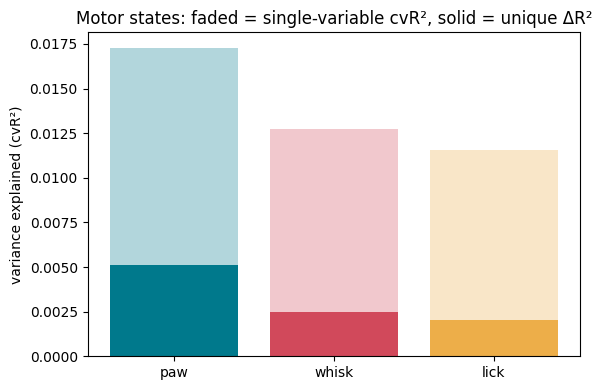

In [12]:
# Overall bar: unique dR2 (solid) + single-variable cvR2 (faded), per state
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'paw': '#00798c', 'whisk': '#d1495b', 'lick': '#edae49'}
x = np.arange(len(STATES))
ax.bar(x, [R[f'r2_{s}_only'].mean() for s in STATES], color=[colors[s] for s in STATES], alpha=.30)
ax.bar(x, [R[f'dR2_{s}'].mean() for s in STATES], color=[colors[s] for s in STATES])
ax.set_xticks(x); ax.set_xticklabels(STATES)
ax.set(ylabel='variance explained (cvR²)',
       title='Motor states: faded = single-variable cvR², solid = unique ΔR²')
plt.tight_layout(); plt.show()

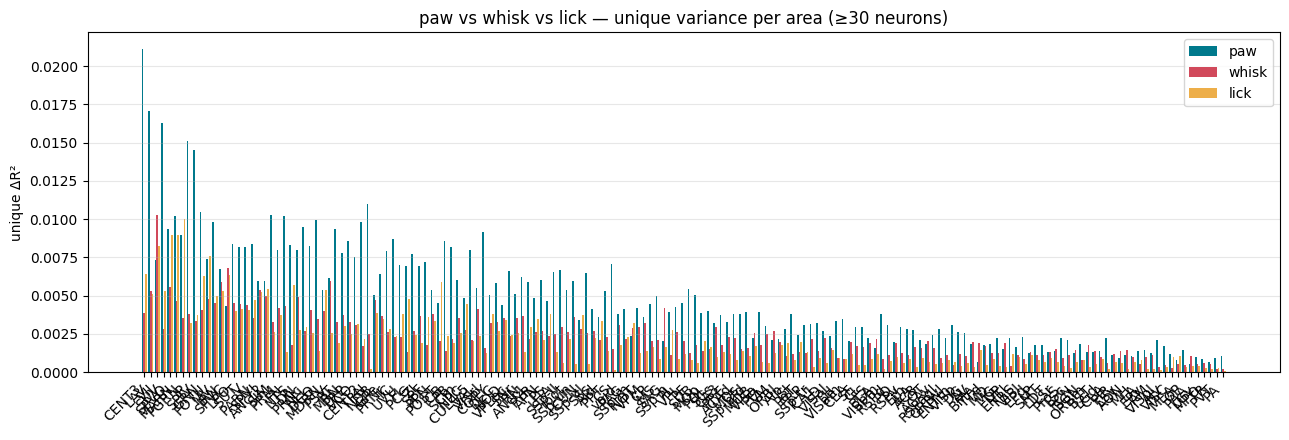

,dR2_paw,dR2_whisk,dR2_lick
beryl,,,
CENT3,0.0211,0.0038,0.0064
LAV,0.0170,0.0053,0.0051
VII,0.0073,0.0103,0.0083
SUV,0.0163,0.0028,0.0053
SPVO,0.0093,0.0056,0.0090
...,...,...,...
LGv,0.0010,0.0005,0.0004
MPO,0.0008,0.0006,0.0003
TR,0.0007,0.0005,0.0002


In [13]:
# Per-area (Beryl) unique dR2 for paw/whisk/lick (areas with >=30 neurons)
counts = R.groupby('beryl').size()
keep_areas = counts[counts >= 30].index
sub = R[R['beryl'].isin(keep_areas)]
agg = sub.groupby('beryl')[[f'dR2_{s}' for s in STATES]].mean()
agg = agg.loc[agg.sum(1).sort_values(ascending=False).index]
xa = np.arange(len(agg)); w = 0.8 / len(STATES)
fig, ax = plt.subplots(figsize=(13, 4.5))
for i, s in enumerate(STATES):
    ax.bar(xa + (i - 1) * w, agg[f'dR2_{s}'], w, label=s, color=colors[s])
ax.set_xticks(xa); ax.set_xticklabels(agg.index, rotation=45, ha='right')
ax.set(ylabel='unique ΔR²', title='paw vs whisk vs lick — unique variance per area (≥30 neurons)')
ax.legend(); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()
agg.round(4)

## Correlation of each variable's explanatory power with LDA1

For each variable (task, paw, whisk, lick) relate its **single-variable cvR²**
(explanatory power) to LDA1 — session-stratified permutation + partial-correlation
JZS Bayes factor, controlling for brain region (Beryl) + `n_bins`, BH-FDR over the
four variables. Single-var (not unique ΔR²) because it's the clean per-variable
coupling, not confounded by how redundant the variables are with each other.

In [14]:
from statsmodels.stats.multitest import multipletests

lda = pd.read_pickle(prefix + 'representation_learning_variability/paper-individuality/'
                     'clustering/mouse_LDA_5_bins_cut06-07-2026').rename(columns={0: 'lda_1'})

# region control at Beryl level; drop unassigned (root)
Rl = R.copy()
Rl['area'] = Rl['beryl']
Rl = Rl[Rl['area'].notna() & (Rl['area'] != 'root')]

VARS = ['task', 'paw', 'whisk', 'lick']
rows = [ef.lda1_perm_bf(Rl, lda, target=f'r2_{v}_only', region_col='area',
                        extra_covars=('n_bins',), perm_group='session',
                        min_area_n=0, n_perm=2000) for v in VARS]
lda_corr = pd.DataFrame(rows)
lda_corr['variable'] = VARS
lda_corr['q_BH'] = multipletests(lda_corr['p_perm'], method='fdr_bh')[1]
lda_corr[['variable', 'n_groups', 'r_partial', 'bf10', 'bf_evidence', 'p_perm', 'q_BH']].round(4)

[r2_task_only  ] slope=-0.0001116  r_partial=-0.009  BF10=0.0287 (strong H0)  p_perm=0.5635  | 34630 neurons, 244 sessions
[r2_paw_only   ] slope=-0.0001659  r_partial=-0.018  BF10=1.87 (inconclusive)  p_perm=0.2340  | 34630 neurons, 244 sessions
[r2_whisk_only ] slope=-0.0003181  r_partial=-0.042  BF10=6.39e+10 (strong H1)  p_perm=0.0030  | 34630 neurons, 244 sessions
[r2_lick_only  ] slope=-3.938e-05  r_partial=-0.005  BF10=0.0096 (strong H0)  p_perm=0.7245  | 34630 neurons, 244 sessions


,variable,n_groups,r_partial,bf10,bf_evidence,p_perm,q_BH
0,task,244,-0.0092,2.870000e-02,strong H0,0.5635,0.7245
1,paw,244,-0.0181,1.873500e+00,inconclusive,0.2340,0.4680
2,whisk,244,-0.0417,6.386355e+10,strong H1,0.0030,0.0120
3,lick,244,-0.0045,9.600000e-03,strong H0,0.7245,0.7245


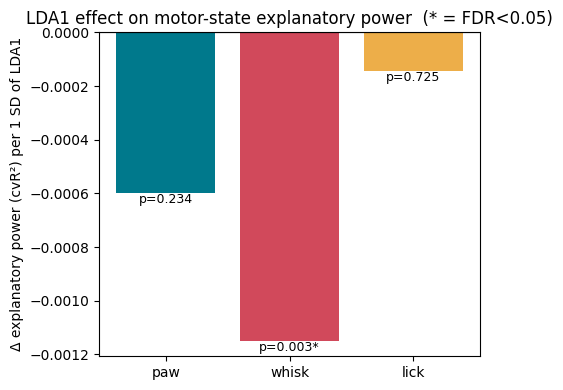

In [15]:
# Bar plot: LDA1 effect on each motor state's explanatory power.
# Show the SLOPE (the statistic the permutation test + FDR are computed on), scaled to
# "per 1 SD of LDA1" for readability (constant scaling -> doesn't change bars/stars).
PLOT_VARS = ['paw', 'whisk', 'lick']          # motor states only (task excluded)
cmap = {'paw': '#00798c', 'whisk': '#d1495b', 'lick': '#edae49'}
used = lda[lda['session'].isin(Rl['session'].unique())].drop_duplicates('session')
sd_lda = used['lda_1'].std()

d = lda_corr.set_index('variable').loc[PLOT_VARS]
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(PLOT_VARS, d['slope'] * sd_lda, color=[cmap[v] for v in PLOT_VARS])
for v, b in zip(PLOT_VARS, bars):
    star = '*' if d.loc[v, 'q_BH'] < 0.05 else ''
    h = b.get_height()
    ax.annotate(f"p={d.loc[v, 'p_perm']:.3f}{star}", (b.get_x() + b.get_width()/2, h),
                ha='center', va='bottom' if h >= 0 else 'top', fontsize=9)
ax.axhline(0, color='k', lw=.8)
ax.set(ylabel='Δ explanatory power (cvR²) per 1 SD of LDA1',
       title="LDA1 effect on motor-state explanatory power  (* = FDR<0.05)")
plt.tight_layout()
plt.show()